In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import sklearn.metrics as skm
from tqdm import tqdm
import time
from itertools import combinations
from scipy.stats import t, sem
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import boto3
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr, zscore

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2024-03-11 20:03:26.124484


### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [4]:
def custom_mapping_ltv(flt_ltv):
    if flt_ltv <= 1.0:
        return 1.0
    elif flt_ltv <= 1.10:
        return 1.10
    elif flt_ltv <= 1.20:
        return 1.20
    elif flt_ltv <= 1.30:
        return 1.30
    else:
        return 1.50

In [5]:
def fit_linear_model(list_month_number, list_mean):
    # init
    cls_model = LinearRegression()
    X = pd.DataFrame({'month_number': list_month_number})
    y = list_mean
    cls_model.fit(X, y)
    flt_int = cls_model.intercept_
    flt_coef = cls_model.coef_[0]
    return flt_int, flt_coef

In [6]:
def extrapolate(tpl_model, int_target_month):
    flt_int = tpl_model[0]
    flt_coef = tpl_model[1]
    return flt_int + (flt_coef * int_target_month)

In [7]:
def fit_simple_linear_model(df, str_iv):
    # tmp
    df_tmp = df.copy()
    # data split
    df_train = df_tmp[df_tmp['data_set'] == 'train'].copy()
    df_valid = df_tmp[df_tmp['data_set'] == 'valid'].copy()
    df_test = df_tmp[df_tmp['data_set'] == 'test'].copy()
    # list cols in model
    list_cols = [
        str_iv,
    ]
    # init
    cls_model = LinearRegression()
    # fit
    cls_model.fit(
        df_train[list_cols], 
        df_train['target'],
    )
    # predict
    y_hat_train = cls_model.predict(df_train[list_cols])
    y_hat_valid = cls_model.predict(df_valid[list_cols])
    y_hat_test = cls_model.predict(df_test[list_cols])
    # get scores
    flt_score_train = np.sqrt(skm.mean_squared_error(
        y_true=df_train['target'], 
        y_pred=y_hat_train,
    ))
    flt_score_valid = np.sqrt(skm.mean_squared_error(
        y_true=df_valid['target'], 
        y_pred=y_hat_valid,
    ))
    flt_score_test = np.sqrt(skm.mean_squared_error(
        y_true=df_test['target'], 
        y_pred=y_hat_test,
    ))
    print(f'IV: {str_iv}')
    print(f'Train: {flt_score_train:0.4f}')
    print(f'Valid: {flt_score_valid:0.4f}')
    print(f'Test: {flt_score_test:0.4f}')
    flt_int = cls_model.intercept_
    print(f'Intercept: {flt_int:0.4f}')
    flt_coef = cls_model.coef_[0]
    print(f'Coefficient: {flt_coef:0.4f}')
    return flt_score_train, flt_score_valid, flt_score_test

### Constants

In [8]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
flt_lgd_constant = 0.4324
str_model = '02_pricing_pd'
str_join_type = 'inner' # inner subsets only those accounts that go to loss

Project: 20231010-gen-xii
Task: ad_hoc


### Output directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [10]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get preprocessor

In [11]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

100%|██████████| 2/2 [00:00<00:00,  5.23it/s]


### Get target pulled from DB

In [12]:
# get targets
list_cols = [
    'bigAccountId',
    'fltNetChgOff',
]
str_filename = 'df_loss.csv'
str_uri = f's3://{str_project}/ad_hoc/linear_ecnl_transformation/01_linear_transformations/{str_filename}'
df_target = pd.read_csv(
    str_uri, 
    usecols=list_cols,
)
dict_rename = {
    'fltNetChgOff': 'target',
}
df_target.rename(columns=dict_rename, inplace=True)
# get mean
flt_mean_target = df_target['target'].mean()
print(f'The mean of the target in all funded loans is {flt_mean_target:0.4f}')
# show
df_target

The mean of the target in all funded loans is 8622.5397


,bigAccountId,target
0,914657,11652.01
1,914668,8788.29
2,914681,-2580.23
3,914771,-198.38
4,914777,7553.05
...,...,...
111269,6704534,13240.17
111270,6705646,15572.47
111271,6705943,8188.41
111272,6706216,8165.90


### Load in data

In [13]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_df = []
for str_df in tqdm(list_str_df):
    str_filename = f'df_{str_df}_raw.gzip'
    str_uri = f's3://{str_project}/{str_model}/01_data_prep/03_train_valid_test_split/{str_filename}'
    df = pd.read_parquet(str_uri)
    # subset to funded loans only
    df['data_set'] = str_df
    list_df.append(df)
df = pd.concat(list_df)

list_cols = [
    'decision_dte__base',
    'open_dte__base',
    'acct_typ_cde__base',
    'terms_freq_cde__base',
    'dtmstampcreation__base',
    'dtmapproved__base',
    'dtmdeclined__base',
    'observationdate__base',
    'analyticsmatchkey__base',
    'booked__base',
    'curr_bal_amt__base',
    'affil_rem_cde__base',
    'cmplnc_rem_cde__base',
    'gnrc_rem_cde__base',
    'rte_rem_cde__base',
    'acct_rte_prfl_cde__base',
    'payt_pttrn_txt__base',
    'gnrcrem_frsrpt_dte__base',
    'obs_arch__base',
    'vtg4__base',
    'performance__base',
    'creditasofdate__tu',
    'credit_as_of_date__tu',
    'strname__tu',
    'state__tu',
    'target',
]
df.drop(list_cols, axis=1, inplace=True)
df.sort_values(by='uniqueid', ascending=True, inplace=True)
df.drop_duplicates(subset=['uniqueid'], keep='last', inplace=True)

# set to string
df['intopenbktype__app'] = df['intopenbktype__app'].astype(str)
# show
df

100%|██████████| 3/3 [00:05<00:00,  1.86s/it]


,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,fltapproveddowntotal__app,payment__app,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,data_set
1,NaN,NaN,NaN,NaN,REYNOLDSBURG,NaN,NaN,NaN,NaN,NaN,...,2000.0,398.83,0.229354,0.052130,1,1.106635,auto,0,2012-06-18 09:31:54.393,train
3,NaN,NaN,NaN,NaN,ENGLEWOOD,NaN,NaN,NaN,NaN,NaN,...,0.0,420.66,0.470570,0.153369,1,1.254334,auto,1,2012-03-06 16:36:21.623,train
5,NaN,NaN,NaN,NaN,RICHARDSON,NaN,NaN,NaN,NaN,NaN,...,0.0,440.04,0.405641,0.050115,0,1.249982,auto,0,2009-10-15 16:06:40.767,train
6,NaN,NaN,NaN,NaN,SILVER CREEK,NaN,NaN,NaN,NaN,NaN,...,NaN,483.21,0.323628,0.137320,1,1.348074,auto,0,2012-11-28 17:21:08.587,train
7,NaN,NaN,NaN,NaN,MELROSE PARK,NaN,NaN,NaN,NaN,NaN,...,1500.0,530.00,0.353894,0.128363,0,0.936749,auto,0,2010-02-19 17:19:40.037,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124310,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,2000.0,514.00,0.470167,0.081653,0,1.102534,auto,1,2007-04-30 08:49:27.647,test
124312,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,3500.0,573.97,0.360741,0.079448,0,0.911393,suv,1,2010-07-30 13:50:37.207,test
124313,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,0.0,447.44,0.172283,0.090964,1,1.188462,auto,1,2013-07-24 10:29:42.193,test
124314,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,0.0,444.98,0.496912,0.144283,1,1.145956,auto,0,2006-09-09 11:59:48.000,test


### Join to target

In [14]:
df['bigaccountid__app'] = df['bigaccountid__app'].astype(int)
df_target['bigAccountId'] = df_target['bigAccountId'].astype(int)
df = pd.merge(
    left=df,
    right=df_target,
    left_on='bigaccountid__app',
    right_on='bigAccountId',
    how=str_join_type,
)
df['target'].fillna(0, inplace=True)
# get loss into proportion of amt financed
df['target'] = df['target'] / df['amtfinanced__app']
# show
df

,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,data_set,bigAccountId,target
0,NaN,NaN,NaN,NaN,REYNOLDSBURG,NaN,NaN,NaN,NaN,NaN,...,0.229354,0.052130,1,1.106635,auto,0,2012-06-18 09:31:54.393,train,1337511,0.608882
1,NaN,NaN,NaN,NaN,ENGLEWOOD,NaN,NaN,NaN,NaN,NaN,...,0.470570,0.153369,1,1.254334,auto,1,2012-03-06 16:36:21.623,train,1337528,0.468471
2,NaN,NaN,NaN,NaN,RICHARDSON,NaN,NaN,NaN,NaN,NaN,...,0.405641,0.050115,0,1.249982,auto,0,2009-10-15 16:06:40.767,train,1337539,0.522535
3,NaN,NaN,NaN,NaN,SILVER CREEK,NaN,NaN,NaN,NaN,NaN,...,0.323628,0.137320,1,1.348074,auto,0,2012-11-28 17:21:08.587,train,1337542,0.658865
4,NaN,NaN,NaN,NaN,LOUISVILLE,NaN,NaN,NaN,NaN,NaN,...,0.450036,0.079333,0,0.434682,auto,0,2012-11-21 13:38:42.487,train,1337579,-0.227752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34778,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,0.414999,0.121849,1,1.245883,suv,1,2013-09-03 15:22:59.433,test,3390549,-0.029156
34779,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,0.426634,0.135930,0,1.142454,suv,1,2013-02-18 16:07:17.973,test,3391105,0.184490
34780,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,0.366126,0.061000,1,1.150000,auto,1,2014-04-02 15:49:48.570,test,3391783,-0.349812
34781,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,0.496912,0.144283,1,1.145956,auto,0,2006-09-09 11:59:48.000,test,3397518,0.534269


### Preprocess

In [15]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))
# rm
os.remove(str_local_path)

# preprocess
list_target = list(df['target'])
list_cols = [col for col in df.columns if col != 'target']
df = cls_model_preprocessing.transform(df[list_cols])
df['target'] = list_target

# rm
os.remove('./preprocessing.py')

# show
df

100%|██████████| 2/2 [00:00<00:00, 11.94it/s]


NaN Replacer: 0.78881 sec.


100%|██████████| 3/3 [00:00<00:00, 121.99it/s]

Set strings: 0.026566 sec.


Boolean Replacer: 0.98887 sec.


...


100%|██████████| 2457/2457 [00:01<00:00, 1589.05it/s]


Replace inf and -inf with NaN: 1.9636 sec.
Imputer: 0.68618 sec.
Map term: 0.018408 sec.
Map PTI: 0.019573 sec.


100%|██████████| 9/9 [00:00<00:00, 1701.47it/s]

Round values: 0.0088632 sec.
Preprocessing Model: 9.165 sec.


,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,bigAccountId,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target
0,0.0,0.0,0.0,0.0,reynoldsburg,0.0,0.0,0.0,0.0,0.0,...,1337511,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,0.608882
1,0.0,0.0,0.0,0.0,englewood,0.0,0.0,0.0,0.0,0.0,...,1337528,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.468471
2,0.0,0.0,0.0,0.0,richardson,0.0,0.0,0.0,0.0,0.0,...,1337539,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.522535
3,0.0,0.0,0.0,0.0,silvercreek,0.0,0.0,0.0,0.0,0.0,...,1337542,2013,1.256262,10,4,0.12,1.588235,2.0,0.838356,0.658865
4,0.0,0.0,0.0,0.0,louisville,0.0,0.0,0.0,0.0,0.0,...,1337579,2013,1.256262,10,4,0.06,0.518519,5.0,0.857534,-0.227752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34778,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,3390549,2017,1.193925,10,4,0.12,1.500000,1.0,4.139726,-0.029156
34779,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,3391105,2017,1.193925,10,4,0.12,1.261905,2.0,4.679452,0.184490
34780,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,3391783,2017,1.193925,10,4,0.06,1.378378,3.0,3.561644,-0.349812
34781,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,3397518,2017,1.193925,10,4,0.15,1.366667,1.0,11.139726,0.534269


### Rm outliers in loss and clip to 0

In [16]:
# target
df['z_tmp'] = zscore(df['target']).abs()
df = df[df['z_tmp'] <= 3].copy()

# clip negatives to 0
df['target'] = df['target'].clip(lower=0)

# show
df

,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target,z_tmp
0,0.0,0.0,0.0,0.0,reynoldsburg,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,0.608882,0.412957
1,0.0,0.0,0.0,0.0,englewood,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.468471,0.105253
2,0.0,0.0,0.0,0.0,richardson,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.522535,0.094280
3,0.0,0.0,0.0,0.0,silvercreek,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.12,1.588235,2.0,0.838356,0.658865,0.597426
4,0.0,0.0,0.0,0.0,louisville,0.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.06,0.518519,5.0,0.857534,0.000000,2.674771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34777,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,2017,1.193925,10,4,0.09,1.178571,5.0,3.079452,0.329952,0.616476
34778,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,2017,1.193925,10,4,0.12,1.500000,1.0,4.139726,0.000000,1.941821
34779,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,2017,1.193925,10,4,0.12,1.261905,2.0,4.679452,0.184490,1.153326
34781,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,2017,1.193925,10,4,0.15,1.366667,1.0,11.139726,0.534269,0.137585


### Get PD predictions

In [17]:
# get gen 12 PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['pd'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

,firstname__tu,middlename__tu,lastname__tu,address1__tu,city__tu,zip5__tu,zip4__tu,ssn__tu,dateofbirth__tu,dtmstampcreation__tu,...,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target,z_tmp,pd
0,0.0,0.0,0.0,0.0,reynoldsburg,0.0,0.0,0.0,0.0,0.0,...,1.256262,10,4,0.09,1.370370,4.0,1.284932,0.608882,0.412957,0.513062
1,0.0,0.0,0.0,0.0,englewood,0.0,0.0,0.0,0.0,0.0,...,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.468471,0.105253,0.310533
2,0.0,0.0,0.0,0.0,richardson,0.0,0.0,0.0,0.0,0.0,...,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.522535,0.094280,0.706639
3,0.0,0.0,0.0,0.0,silvercreek,0.0,0.0,0.0,0.0,0.0,...,1.256262,10,4,0.12,1.588235,2.0,0.838356,0.658865,0.597426,0.448451
4,0.0,0.0,0.0,0.0,louisville,0.0,0.0,0.0,0.0,0.0,...,1.256262,10,4,0.06,0.518519,5.0,0.857534,0.000000,2.674771,0.548137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34777,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,1.193925,10,4,0.09,1.178571,5.0,3.079452,0.329952,0.616476,0.163388
34778,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,1.193925,10,4,0.12,1.500000,1.0,4.139726,0.000000,1.941821,0.346814
34779,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,1.193925,10,4,0.12,1.261905,2.0,4.679452,0.184490,1.153326,0.424505
34781,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,0.0,0.0,...,1.193925,10,4,0.15,1.366667,1.0,11.139726,0.534269,0.137585,0.441041


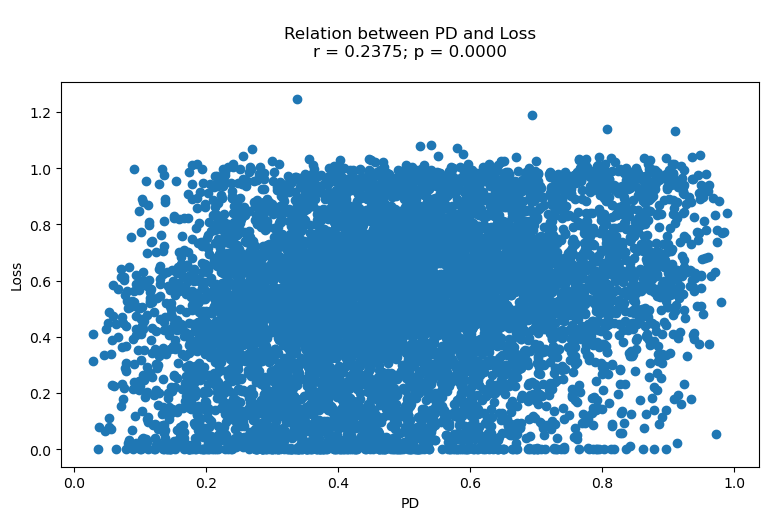

In [18]:
# look at relation of PD to loss
df_tmp = df[df['data_set'] == 'valid'].copy()
flt_coef, flt_p = pearsonr(df_tmp['pd'], df_tmp['target'])
str_title = f"""
Relation between PD and Loss
r = {flt_coef:0.4f}; p = {flt_p:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('PD')
ax.set_ylabel('Loss')
ax.scatter(df_tmp['pd'], df_tmp['target'])
plt.show()

### Get LGD predictions

In [19]:
# get gen 12 LGD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['lgd'] = cls_model_inference.predict(df[list_cols_model])
# subset
list_cols = [
    'bigaccountid__app',
    'applicationdate__app',
    'data_set',
    'intopenbktype__app',
    'pd',
    'lgd',
    'ENG-loan_to_value',
    'fltapproveddowntotal__app',
    'fltdowncash__app',
    'target',
]
df = df[list_cols].copy()
# show
df

,bigaccountid__app,applicationdate__app,data_set,intopenbktype__app,pd,lgd,ENG-loan_to_value,fltapproveddowntotal__app,fltdowncash__app,target
0,1337511.0,2013-10-01 07:28:54.833,train,nan,0.513062,0.419317,1.370370,2500.0,2500.0,0.608882
1,1337528.0,2013-10-01 08:25:39.117,train,7.0,0.310533,0.346931,1.586207,0.0,0.0,0.468471
2,1337539.0,2013-10-01 08:39:13.390,train,nan,0.706639,0.471772,1.342857,0.0,0.0,0.522535
3,1337542.0,2013-10-01 08:43:26.223,train,nan,0.448451,0.360220,1.588235,0.0,0.0,0.658865
4,1337579.0,2013-10-01 09:12:09.627,train,13.0,0.548137,0.168220,0.518519,9000.0,9500.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
34777,3388531.0,2017-10-21 14:49:07.927,test,nan,0.163388,0.359555,1.178571,2500.0,1000.0,0.329952
34778,3390549.0,2017-10-23 16:22:51.057,test,7.0,0.346814,0.219123,1.500000,500.0,500.0,0.000000
34779,3391105.0,2017-10-24 09:51:23.960,test,7.0,0.424505,0.423995,1.261905,0.0,0.0,0.184490
34781,3397518.0,2017-10-28 10:30:35.503,test,7.0,0.441041,0.481834,1.366667,0.0,0.0,0.534269


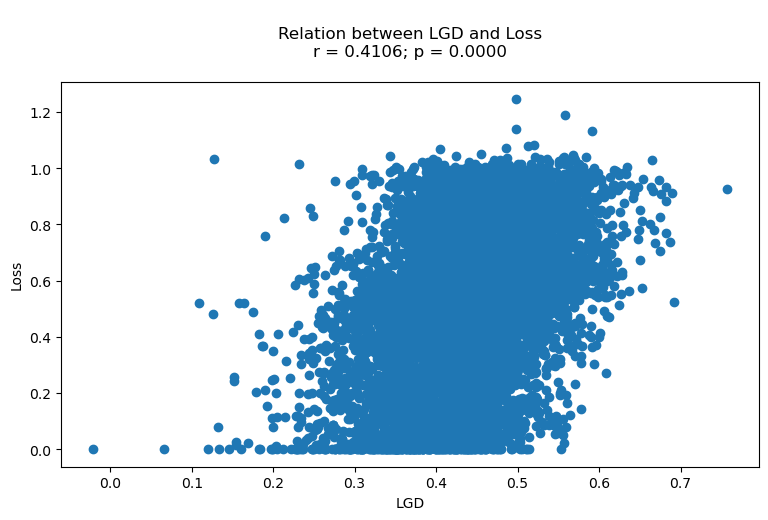

In [20]:
# look at relation of LGD to loss
df_tmp = df[df['data_set'] == 'valid'].copy()
flt_coef, flt_p = pearsonr(df_tmp['lgd'], df_tmp['target'])
str_title = f"""
Relation between LGD and Loss
r = {flt_coef:0.4f}; p = {flt_p:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('LGD')
ax.set_ylabel('Loss')
ax.scatter(df_tmp['lgd'], df_tmp['target'])
plt.show()

### Assign LGD constant

In [21]:
df['lgd_constant'] = flt_lgd_constant
df

,bigaccountid__app,applicationdate__app,data_set,intopenbktype__app,pd,lgd,ENG-loan_to_value,fltapproveddowntotal__app,fltdowncash__app,target,lgd_constant
0,1337511.0,2013-10-01 07:28:54.833,train,nan,0.513062,0.419317,1.370370,2500.0,2500.0,0.608882,0.4324
1,1337528.0,2013-10-01 08:25:39.117,train,7.0,0.310533,0.346931,1.586207,0.0,0.0,0.468471,0.4324
2,1337539.0,2013-10-01 08:39:13.390,train,nan,0.706639,0.471772,1.342857,0.0,0.0,0.522535,0.4324
3,1337542.0,2013-10-01 08:43:26.223,train,nan,0.448451,0.360220,1.588235,0.0,0.0,0.658865,0.4324
4,1337579.0,2013-10-01 09:12:09.627,train,13.0,0.548137,0.168220,0.518519,9000.0,9500.0,0.000000,0.4324
...,...,...,...,...,...,...,...,...,...,...,...
34777,3388531.0,2017-10-21 14:49:07.927,test,nan,0.163388,0.359555,1.178571,2500.0,1000.0,0.329952,0.4324
34778,3390549.0,2017-10-23 16:22:51.057,test,7.0,0.346814,0.219123,1.500000,500.0,500.0,0.000000,0.4324
34779,3391105.0,2017-10-24 09:51:23.960,test,7.0,0.424505,0.423995,1.261905,0.0,0.0,0.184490,0.4324
34781,3397518.0,2017-10-28 10:30:35.503,test,7.0,0.441041,0.481834,1.366667,0.0,0.0,0.534269,0.4324


### Group

In [22]:
df = df.groupby(by='bigaccountid__app', as_index=False).agg({
    'data_set': 'first',
    'intopenbktype__app': 'first',
    'pd': 'mean',
    'lgd': 'mean',
    'lgd_constant': 'mean',
    'target': 'first',
})
df

,bigaccountid__app,data_set,intopenbktype__app,pd,lgd,lgd_constant,target
0,1337511.0,train,nan,0.513062,0.419317,0.4324,0.608882
1,1337528.0,train,7.0,0.310533,0.346931,0.4324,0.468471
2,1337539.0,train,nan,0.706639,0.471772,0.4324,0.522535
3,1337542.0,train,nan,0.448451,0.360220,0.4324,0.658865
4,1337579.0,train,13.0,0.548137,0.168220,0.4324,0.000000
...,...,...,...,...,...,...,...
34684,3388531.0,test,nan,0.163388,0.359555,0.4324,0.329952
34685,3390549.0,test,7.0,0.346814,0.219123,0.4324,0.000000
34686,3391105.0,test,7.0,0.424505,0.423995,0.4324,0.184490
34687,3397518.0,test,7.0,0.441041,0.481834,0.4324,0.534269


### Get ECNL

In [23]:
df['ecnl'] = df['pd'] * df['lgd']
df['ecnl_constant'] = df['pd'] * df['lgd_constant']
list_cols = [
    'data_set',
    'intopenbktype__app',
    'ecnl',
    'ecnl_constant',
    'target',
]
df = df[list_cols].copy()
df

,data_set,intopenbktype__app,ecnl,ecnl_constant,target
0,train,nan,0.215136,0.221848,0.608882
1,train,7.0,0.107734,0.134275,0.468471
2,train,nan,0.333372,0.305551,0.522535
3,train,nan,0.161541,0.193910,0.658865
4,train,13.0,0.092207,0.237014,0.000000
...,...,...,...,...,...
34684,test,nan,0.058747,0.070649,0.329952
34685,test,7.0,0.075995,0.149962,0.000000
34686,test,7.0,0.179988,0.183556,0.184490
34687,test,7.0,0.212509,0.190706,0.534269


### Plot distributions

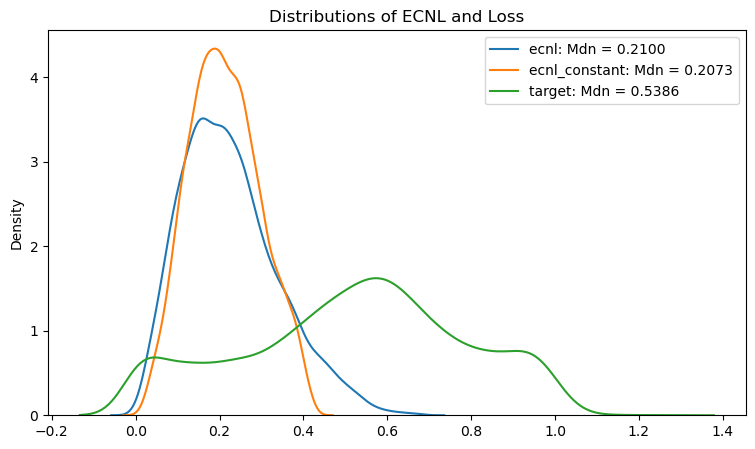

In [24]:
df_tmp = df[df['data_set'] == 'valid'].copy()
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of ECNL and Loss')
list_cols = [
    'ecnl',
    'ecnl_constant',
    'target',
]
for col in list_cols:
    flt_mdn = df_tmp[col].median()
    sns.kdeplot(list(df_tmp[col]), ax=ax, label=f'{col}: Mdn = {flt_mdn:0.4f}')
# legend
plt.legend()
# show
plt.show()

### Residuals

In [25]:
df['ecnl_residual'] = df['ecnl'] - df['target']
df['ecnl_constant_residual'] = df['ecnl_constant'] - df['target']
df

,data_set,intopenbktype__app,ecnl,ecnl_constant,target,ecnl_residual,ecnl_constant_residual
0,train,nan,0.215136,0.221848,0.608882,-0.393746,-0.387034
1,train,7.0,0.107734,0.134275,0.468471,-0.360737,-0.334196
2,train,nan,0.333372,0.305551,0.522535,-0.189162,-0.216984
3,train,nan,0.161541,0.193910,0.658865,-0.497324,-0.464954
4,train,13.0,0.092207,0.237014,0.000000,0.092207,0.237014
...,...,...,...,...,...,...,...
34684,test,nan,0.058747,0.070649,0.329952,-0.271205,-0.259304
34685,test,7.0,0.075995,0.149962,0.000000,0.075995,0.149962
34686,test,7.0,0.179988,0.183556,0.184490,-0.004503,-0.000934
34687,test,7.0,0.212509,0.190706,0.534269,-0.321760,-0.343562


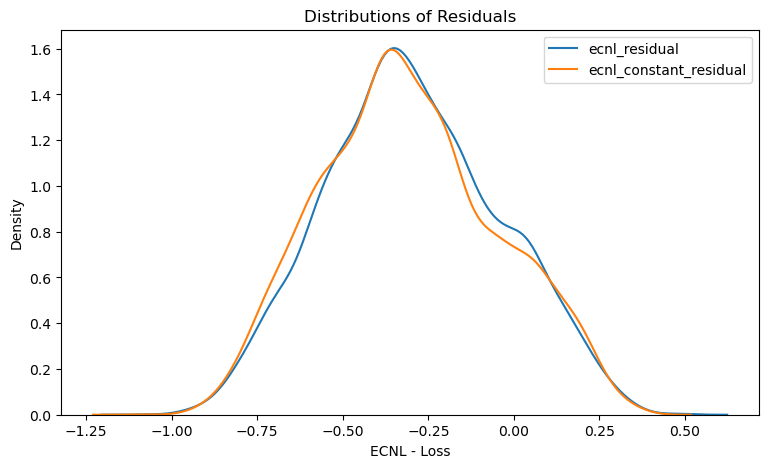

In [26]:
# plot residuals
df_tmp = df[df['data_set'] == 'valid'].copy()
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Residuals')
ax.set_xlabel('ECNL - Loss')
list_cols = [
    'ecnl_residual',
    'ecnl_constant_residual',
]
for col in list_cols:
    sns.kdeplot(list(df_tmp[col]), ax=ax, label=col)
# legend
plt.legend()
# show
plt.show()

### Get the medians by segment

In [27]:
list_str_segment = [
    '7.0',
    '13.0',
    'nan',
]
list_dict_row = []
for str_segment in list_str_segment:
    df_tmp = df[df['intopenbktype__app'] == str_segment].copy()
    flt_mdn_ecnl = df_tmp['ecnl'].median()
    flt_mdn_ecnl_constant = df_tmp['ecnl_constant'].median()
    flt_median_target = df_tmp['target'].median()
    dict_row = {
        'str_segment': str_segment,
        'flt_mdn_ecnl': flt_mdn_ecnl,
        'flt_mdn_ecnl_constant': flt_mdn_ecnl_constant,
        'flt_median_target': flt_median_target,
    }
    list_dict_row.append(dict_row)
df_mdns = pd.DataFrame(list_dict_row)
df_mdns['flt_mdn_ecnl_factor'] = df_mdns['flt_median_target'] - df_mdns['flt_mdn_ecnl']
df_mdns['flt_mdn_ecnl_constant_factor'] = df_mdns['flt_median_target'] - df_mdns['flt_mdn_ecnl_constant']
df_mdns

,str_segment,flt_mdn_ecnl,flt_mdn_ecnl_constant,flt_median_target,flt_mdn_ecnl_factor,flt_mdn_ecnl_constant_factor
0,7.0,0.232799,0.227366,0.533896,0.301098,0.306530
1,13.0,0.204622,0.227135,0.470934,0.266312,0.243800
2,nan,0.211295,0.211614,0.523316,0.312021,0.311702


### Plot shifted distributions

In [28]:
dict_map_ecnl = dict(zip(df_mdns['str_segment'], df_mdns['flt_mdn_ecnl_factor']))
dict_map_ecnl_constant = dict(zip(df_mdns['str_segment'], df_mdns['flt_mdn_ecnl_constant_factor']))
df['factor_ecnl'] = df['intopenbktype__app'].map(dict_map_ecnl)
df['factor_ecnl_constant'] = df['intopenbktype__app'].map(dict_map_ecnl_constant)
df['ecnl_shifted'] = df['ecnl'] + df['factor_ecnl']
df['ecnl_constant_shifted'] = df['ecnl_constant'] + df['factor_ecnl_constant']
df

,data_set,intopenbktype__app,ecnl,ecnl_constant,target,ecnl_residual,ecnl_constant_residual,factor_ecnl,factor_ecnl_constant,ecnl_shifted,ecnl_constant_shifted
0,train,nan,0.215136,0.221848,0.608882,-0.393746,-0.387034,0.312021,0.311702,0.527157,0.533550
1,train,7.0,0.107734,0.134275,0.468471,-0.360737,-0.334196,0.301098,0.306530,0.408831,0.440804
2,train,nan,0.333372,0.305551,0.522535,-0.189162,-0.216984,0.312021,0.311702,0.645394,0.617253
3,train,nan,0.161541,0.193910,0.658865,-0.497324,-0.464954,0.312021,0.311702,0.473562,0.505612
4,train,13.0,0.092207,0.237014,0.000000,0.092207,0.237014,0.266312,0.243800,0.358520,0.480814
...,...,...,...,...,...,...,...,...,...,...,...
34684,test,nan,0.058747,0.070649,0.329952,-0.271205,-0.259304,0.312021,0.311702,0.370768,0.382351
34685,test,7.0,0.075995,0.149962,0.000000,0.075995,0.149962,0.301098,0.306530,0.377093,0.456492
34686,test,7.0,0.179988,0.183556,0.184490,-0.004503,-0.000934,0.301098,0.306530,0.481086,0.490086
34687,test,7.0,0.212509,0.190706,0.534269,-0.321760,-0.343562,0.301098,0.306530,0.513606,0.497236


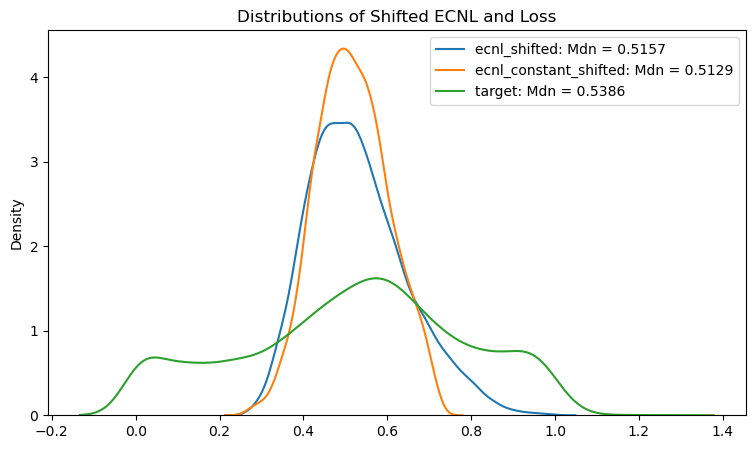

In [29]:
df_tmp = df[df['data_set'] == 'valid'].copy()
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Shifted ECNL and Loss')
list_cols = [
    'ecnl_shifted',
    'ecnl_constant_shifted',
    'target',
]
for col in list_cols:
    flt_mdn = df_tmp[col].median()
    sns.kdeplot(list(df_tmp[col]), ax=ax, label=f'{col}: Mdn = {flt_mdn:0.4f}')
# legend
plt.legend()
# show
plt.show()

### Plot correlations

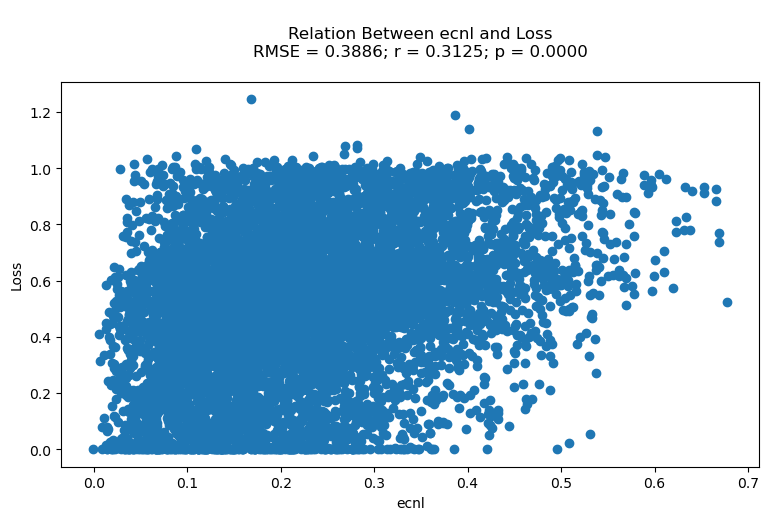

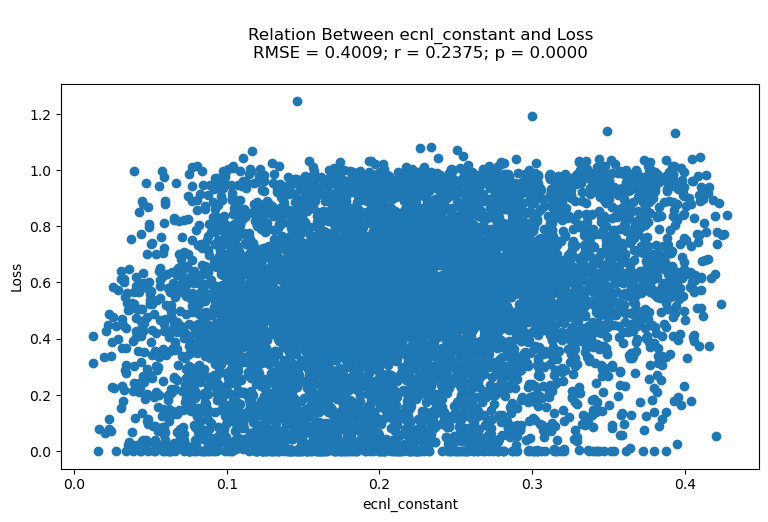

In [30]:
df_tmp = df[df['data_set'] == 'valid'].copy()
list_cols = [
    'ecnl',
    'ecnl_constant',
]
for col in list_cols:
    flt_score = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp[col],
    ))
    flt_coef, flt_p = pearsonr(df_tmp[col], df_tmp['target'])
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Relation Between {col} and Loss
    RMSE = {flt_score:0.4f}; r = {flt_coef:0.4f}; p = {flt_p:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel(col)
    ax.set_ylabel('Loss')
    ax.scatter(df_tmp[col], df_tmp['target'])
    # show
    plt.show()

### No transformation

In [31]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

IV: ecnl
Train: 0.2395
Valid: 0.2541
Test: 0.2624
Intercept: 0.3230
Coefficient: 0.7359

IV: ecnl_constant
Train: 0.2467
Valid: 0.2600
Test: 0.2652
Intercept: 0.3307
Coefficient: 0.7305



### Log

In [32]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    df_tmp[str_iv] = np.log(df_tmp[str_iv])
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

IV: ecnl_constant
Train: 0.2471
Valid: 0.2605
Test: 0.2657
Intercept: 0.7150
Coefficient: 0.1392



### Log10

In [33]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    df_tmp[str_iv] = np.log10(df_tmp[str_iv])
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

IV: ecnl_constant
Train: 0.2471
Valid: 0.2605
Test: 0.2657
Intercept: 0.7150
Coefficient: 0.3206



### Square

In [34]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    df_tmp[str_iv] = df_tmp[str_iv] ** 2
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

IV: ecnl
Train: 0.2412
Valid: 0.2555
Test: 0.2632
Intercept: 0.4109
Coefficient: 1.2407

IV: ecnl_constant
Train: 0.2471
Valid: 0.2604
Test: 0.2656
Intercept: 0.4082
Coefficient: 1.5026



### Square root

In [35]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    df_tmp[str_iv] = np.sqrt(df_tmp[str_iv])
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

IV: ecnl_constant
Train: 0.2468
Valid: 0.2601
Test: 0.2653
Intercept: 0.1859
Coefficient: 0.6651



### Cube

In [36]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    df_tmp[str_iv] = df_tmp[str_iv] ** 3
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

IV: ecnl
Train: 0.2434
Valid: 0.2575
Test: 0.2646
Intercept: 0.4443
Coefficient: 2.2394

IV: ecnl_constant
Train: 0.2477
Valid: 0.2609
Test: 0.2662
Intercept: 0.4367
Coefficient: 3.5943



### Cube root

In [37]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    df_tmp[str_iv] = np.cbrt(df_tmp[str_iv])
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

IV: ecnl
Train: 0.2395
Valid: 0.2542
Test: 0.2627
Intercept: 0.0132
Coefficient: 0.8061

IV: ecnl_constant
Train: 0.2468
Valid: 0.2602
Test: 0.2654
Intercept: 0.0445
Coefficient: 0.7546



### Reciprocal

In [38]:
list_str_iv = [
    'ecnl',
    'ecnl_constant',
]
for str_iv in list_str_iv:
    df_tmp = df.copy()
    df_tmp[str_iv] = 1 / df_tmp[str_iv]
    try:
        flt_score_train, flt_score_valid, flt_score_test = fit_simple_linear_model(
            df=df_tmp, 
            str_iv=str_iv,
        )
    except ValueError as e:
        print(e)
    print()

IV: ecnl
Train: 0.2481
Valid: 0.2977
Test: 0.2689
Intercept: 0.5536
Coefficient: -0.0093

IV: ecnl_constant
Train: 0.2496
Valid: 0.2628
Test: 0.2687
Intercept: 0.5765
Coefficient: -0.0147

